# Checkpoint 02 — APIs de energia renovável e aprendizado de máquina

**Disciplina:** Soluções em Energias Renováveis e Sustentáveis (SERS) — FIAP · Ciência da Computação · 2º semestre

| Integrante | RM |
|---|---|
| Tiago MUhlmann | RM569569 |
| Wesley Marques | RM573915 |
| Marcos Sampaio | RM753987 |
| Otavio Mancilia | RM570225 |
| Gabriela Angel | RM570808 |
| Izabelly Menezes | RM570673 |

Consultamos duas APIs públicas, organizamos os dados e resolvemos **duas tarefas**:

1. **Classificação (ANEEL/SIGA):** prever a fonte de um empreendimento (Solar, Eólica ou Hidráulica) a partir da potência e da localização.
2. **Regressão (Open-Meteo):** estimar a radiação solar horária em Petrolina (PE) a partir de variáveis meteorológicas e da hora.

Em cada tarefa treinamos e comparamos **três algoritmos diferentes** com a mesma divisão de dados.

| Tarefa | Algoritmos | Avaliação |
|---|---|---|
| Classificação | Regressão Logística · kNN · Random Forest | Treino/teste estratificado 80/20, `random_state=42`; Accuracy, Precision, Recall, F1 (média **macro**) e matriz de confusão |
| Regressão | Regressão Linear · Árvore de Decisão · Random Forest | Divisão **temporal**: primeiras 80% das horas para treino, últimas 20% para teste; MAE, MSE e R² |

**Como executar:** abra no Google Colab ou Jupyter e use *Executar tudo*. O notebook tenta consultar as APIs; se a rede bloquear a consulta, ele usa os CSVs versionados no repositório (mesmos dados gerados pelo notebook de apoio).

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**.

A consulta usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python.

In [1]:
import json
import os
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, gera um erro com a mensagem.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Cópia dos CSVs gerados pelo notebook de apoio (usada somente se a API estiver indisponível)
URL_BACKUP = "https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/"

def garantir_csv(nome):
    """Se o CSV não existir localmente (API indisponível), baixa a cópia de segurança."""
    if os.path.exists(nome):
        print(f"Usando o arquivo local {nome}")
    else:
        urllib.request.urlretrieve(URL_BACKUP + nome, nome)
        print(f"Arquivo {nome} baixado da cópia de segurança")

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`, agrupadas na classe *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada, em kW | Entrada `potencia_kw` (potência autorizada, não energia produzida) |
| `NumCoordNEmpreendimento` | Latitude aproximada, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento`, combustível | Código, nome e descrição | **Não usados**: revelariam a classe |

### 1. Consultar a ANEEL
O recurso SIGA é acessado pela API pública CKAN/DataStore: `resource_id` aponta para o conjunto, `filters` seleciona uma sigla e `limit` limita o retorno de cada pedido (1.200 linhas por sigla).

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
try:
    for sigla in SIGLAS:
        parametros = {
            "resource_id": ID_RECURSO,
            "filters": json.dumps({"SigTipoGeracao": sigla}),
            "limit": 1200,
        }
        resposta = consultar_api(URL_ANEEL, parametros)
        if not resposta.get("success"):
            raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
        linhas = resposta["result"]["records"]
        print(f"{sigla}: {len(linhas)} linhas recebidas")
        registros_aneel.extend(linhas)
    print("Total de linhas recebidas:", len(registros_aneel))
except Exception as erro:
    registros_aneel = []
    print("API da ANEEL indisponível neste ambiente:", erro)
    print("A análise usará o CSV versionado no repositório.")

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa
A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}

if registros_aneel:
    linhas_classificacao = []
    for registro in registros_aneel:
        potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
        latitude = numero(registro.get("NumCoordNEmpreendimento"))
        longitude = numero(registro.get("NumCoordEEmpreendimento"))
        fonte = fontes.get(registro.get("SigTipoGeracao"))
        if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
            linhas_classificacao.append([potencia, latitude, longitude, fonte])
    if len(linhas_classificacao) < 90:
        raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
    with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
        escritor = csv.writer(arquivo)
        escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
        escritor.writerows(linhas_classificacao)
    print("Linhas válidas:", len(linhas_classificacao))
    print("Salvo: aneel_classificacao_orange.csv")
else:
    garantir_csv("aneel_classificacao_orange.csv")

Linhas válidas: 3876
Salvo: aneel_classificacao_orange.csv


## 3. Bibliotecas para análise e aprendizado de máquina

A partir daqui está a implementação do grupo. Escolhemos os algoritmos de forma que cada tarefa compare famílias diferentes de modelo:

- **linear** (Regressão Logística / Regressão Linear): referência simples e interpretável;
- **baseado em vizinhança ou árvore única** (kNN / Árvore de Decisão): captura relações não lineares e locais;
- **ensemble** (Random Forest): média de muitas árvores, geralmente mais estável que uma árvore isolada.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Classificação: Regressão Logística, kNN e Random Forest
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Regressão: Regressão Linear, Árvore de Decisão e Random Forest
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEMENTE = 42
os.makedirs("figuras", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
CORES_FONTE = {"Eólica": "#2A9D8F", "Hidráulica": "#3D5A98", "Solar": "#E9A23B"}
CORES_MODELO = ["#8D99AE", "#9B5DE5", "#2D6A4F"]

## 4. Análise exploratória — ANEEL
Carregamos o CSV e verificamos tamanho, tipos, valores ausentes e distribuição das classes.

In [7]:
dados = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")
print("Linhas e colunas:", dados.shape)
dados.info()
dados.head()

Linhas e colunas: (3876, 4)
<class 'pandas.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   str    
dtypes: float64(3), str(1)
memory usage: 121.3 KB


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [8]:
print("Valores ausentes por coluna:")
print(dados.isna().sum())
print("\nLinhas duplicadas:", dados.duplicated().sum())
dados.describe().round(2)

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Linhas duplicadas: 27


,potencia_kw,latitude,longitude
count,3876.00,3876.00,3876.00
mean,41735.71,-12.68,-46.27
std,301650.89,9.52,8.25
min,0.16,-33.72,-69.94
25%,400.00,-21.19,-52.59
50%,12000.00,-10.47,-47.65
75%,30000.00,-4.09,-41.32
max,11233100.00,3.83,0.00


            exemplos  proporção (%)
fonte                              
Hidráulica      1476           38.1
Solar           1200           31.0
Eólica          1200           31.0


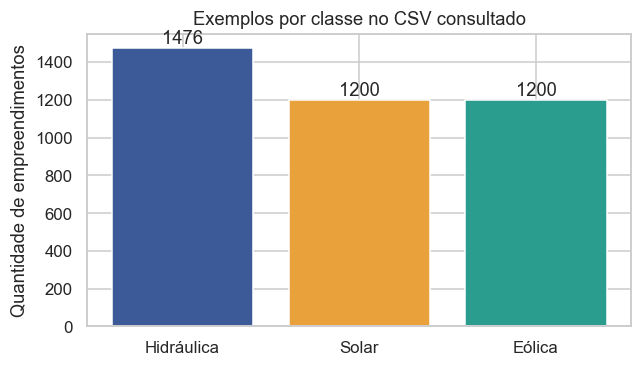

In [9]:
contagem = dados["fonte"].value_counts()
print(pd.DataFrame({"exemplos": contagem, "proporção (%)": (100 * contagem / len(dados)).round(1)}))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(contagem.index, contagem.values, color=[CORES_FONTE[c] for c in contagem.index])
for i, v in enumerate(contagem.values):
    ax.text(i, v + 20, str(v), ha="center")
ax.set_title("Exemplos por classe no CSV consultado")
ax.set_ylabel("Quantidade de empreendimentos")
plt.tight_layout(); plt.savefig("figuras/classes_aneel.png"); plt.show()

**Distribuição das classes:** 3.876 empreendimentos, sem valores ausentes. Solar e Eólica têm 1.200 exemplos cada (o limite de cada consulta) e Hidráulica tem 1.476, porque soma três siglas (UHE, PCH e CGH). O desequilíbrio é pequeno (38,1% contra 31,0%), então a divisão estratificada e a média **macro** são suficientes.

> Essas quantidades vêm do **limite de linhas por consulta**. Elas **não** representam a participação de cada fonte na matriz energética brasileira.

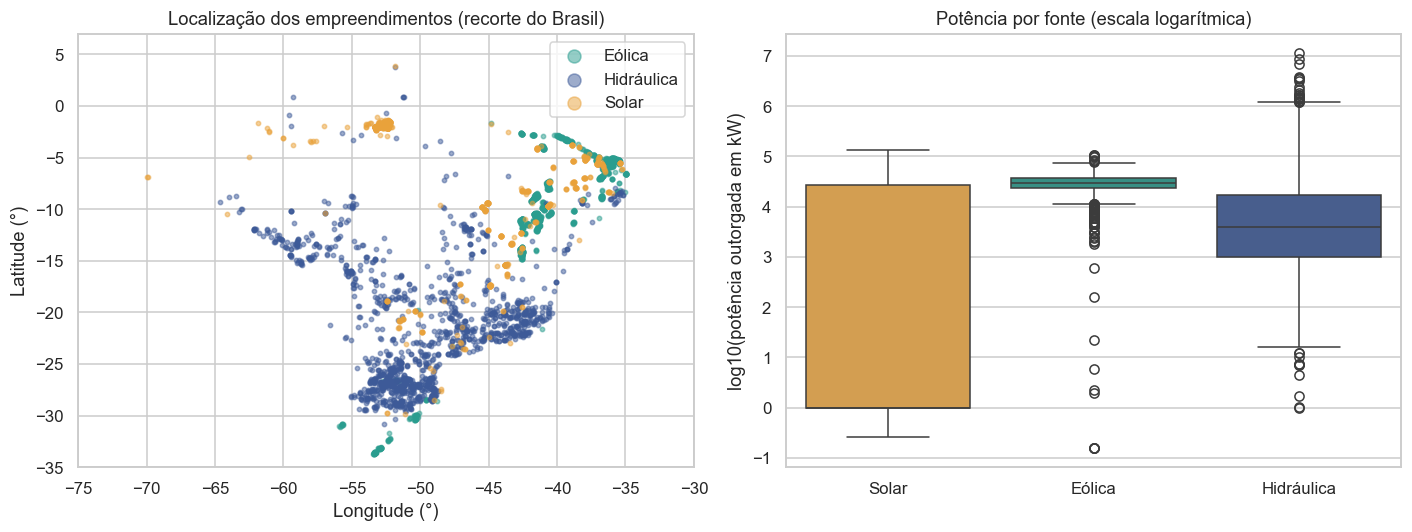

,potencia_kw,latitude,longitude
fonte,,,
Eólica,29600.0,-7.98,-40.69
Hidráulica,4000.0,-22.03,-50.43
Solar,1.0,-2.04,-52.46


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for fonte, grupo in dados.groupby("fonte"):
    axes[0].scatter(grupo["longitude"], grupo["latitude"], s=8, alpha=0.5,
                    color=CORES_FONTE[fonte], label=fonte)
axes[0].set_xlim(-75, -30); axes[0].set_ylim(-35, 7)
axes[0].set_xlabel("Longitude (°)"); axes[0].set_ylabel("Latitude (°)")
axes[0].set_title("Localização dos empreendimentos (recorte do Brasil)")
axes[0].legend(markerscale=3)

dados_log = dados.assign(log10_potencia=np.log10(dados["potencia_kw"]))
sns.boxplot(data=dados_log, x="fonte", y="log10_potencia", hue="fonte",
            palette=CORES_FONTE, ax=axes[1], legend=False)
axes[1].set_ylabel("log10(potência outorgada em kW)")
axes[1].set_xlabel("")
axes[1].set_title("Potência por fonte (escala logarítmica)")
plt.tight_layout(); plt.savefig("figuras/eda_aneel.png"); plt.show()

dados.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].median().round(2)

In [11]:
# Verificações de qualidade dos dados
coord_zero = (dados["latitude"] == 0) & (dados["longitude"] == 0)
print("Empreendimentos com coordenada (0, 0):", coord_zero.sum())
print(dados.loc[coord_zero, "fonte"].value_counts(), "\n")
print("Empreendimentos solares com potência de exatamente 1 kW:",
      ((dados["fonte"] == "Solar") & (dados["potencia_kw"] == 1)).sum())

Empreendimentos com coordenada (0, 0): 44
fonte
Eólica        24
Hidráulica    20
Name: count, dtype: int64 

Empreendimentos solares com potência de exatamente 1 kW: 772


**O que a exploração mostra:**

- **Potência:** eólicas se concentram em torno de 30 MW (mediana 29.600 kW); hidráulicas vão de micro-centrais (CGH, ~1 MW) a usinas gigantes (máximo 11.233.100 kW); a maioria das solares da amostra tem valores muito pequenos (752 registros com exatamente 1 kW). A escala logarítmica é necessária para enxergar isso.
- **Localização:** eólicas aparecem sobretudo no Nordeste e no Sul; hidráulicas no Sul/Sudeste e Centro-Oeste. As solares estão muito agrupadas: **732 das 1.200** ficam numa pequena área do oeste do Pará (lat. ≈ −2°, long. ≈ −53°), e 726 delas têm exatamente 1 kW. Como a consulta traz as **primeiras 1.200 linhas de cada sigla**, a amostra não é aleatória e não representa o parque solar brasileiro.
- **Qualidade:** 47 empreendimentos (eólicos e hidráulicos) têm coordenada (0, 0), um ponto no Oceano Atlântico — é coordenada ausente registrada como zero. Mantivemos essas linhas para usar exatamente o mesmo CSV no Python e no Orange, e testamos o efeito de removê-las no fim da tarefa.

## 5. Definição de X e y e divisão estratificada

- **X (entradas):** `potencia_kw`, `latitude`, `longitude` — três atributos numéricos.
- **y (alvo):** `fonte` — Solar, Eólica ou Hidráulica.

Separamos 80% para treino e 20% para teste com `stratify=y` (mantém a proporção das classes nos dois conjuntos) e `random_state=42` (resultado reproduzível).

In [12]:
X = dados[["potencia_kw", "latitude", "longitude"]]
y = dados["fonte"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEMENTE)

print("Treino:", X_treino.shape[0], "linhas | Teste:", X_teste.shape[0], "linhas")

# Mesma divisão exportada para o Orange (Test & Score com conjunto de teste separado)
os.makedirs("orange", exist_ok=True)
dados.loc[X_treino.index].to_csv("orange/aneel_treino_80.csv", index=False)
dados.loc[X_teste.index].to_csv("orange/aneel_teste_20.csv", index=False)
pd.DataFrame({"treino (%)": (100 * y_treino.value_counts(normalize=True)).round(1),
              "teste (%)": (100 * y_teste.value_counts(normalize=True)).round(1)})

Treino: 3100 linhas | Teste: 776 linhas


,treino (%),teste (%)
fonte,,
Hidráulica,38.1,38.1
Solar,31.0,30.9
Eólica,31.0,30.9


## 6. Os três classificadores

| Modelo | Configuração | Por que escolhemos |
|---|---|---|
| **Regressão Logística** | `StandardScaler` + `LogisticRegression(C=1, max_iter=1000)` | Modelo linear de referência: separa as classes com fronteiras retas. Mostra até onde uma regra simples chega. |
| **kNN** | `StandardScaler` + `KNeighborsClassifier(n_neighbors=5)` | Classifica pelo voto dos 5 vizinhos mais próximos. Bom para padrões geográficos (empreendimentos próximos tendem a ter a mesma fonte). |
| **Random Forest** | `RandomForestClassifier(n_estimators=100, min_samples_split=5, random_state=42)` | Conjunto de 100 árvores; captura limites não lineares (ex.: "potência ~30 MW **e** litoral do NE → Eólica"). |

**Padronização:** Regressão Logística e kNN dependem da escala (a potência vai até milhões de kW, enquanto latitude e longitude ficam em dezenas de graus). Por isso usamos `make_pipeline(StandardScaler(), ...)`: a média e o desvio são calculados **somente no treino** dentro do `fit`, sem vazar informação do teste. A Random Forest não precisa de padronização.

In [13]:
classificadores = {
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000)),
    "kNN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_split=5, random_state=SEMENTE),
}

CLASSES = ["Eólica", "Hidráulica", "Solar"]
previsoes_clf, linhas = {}, []
for nome, modelo in classificadores.items():
    modelo.fit(X_treino, y_treino)
    y_prev = modelo.predict(X_teste)
    previsoes_clf[nome] = y_prev
    linhas.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, y_prev),
        "Precision (macro)": precision_score(y_teste, y_prev, average="macro"),
        "Recall (macro)": recall_score(y_teste, y_prev, average="macro"),
        "F1 (macro)": f1_score(y_teste, y_prev, average="macro"),
    })

resultados_clf = pd.DataFrame(linhas).set_index("Modelo")
resultados_clf.round(4).to_csv("resultados/metricas_classificacao.csv")
resultados_clf.round(4)

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,
Regressão Logística,0.8235,0.8275,0.8200,0.8182
kNN (k=5),0.9665,0.9677,0.9649,0.9662
Random Forest,0.9704,0.9716,0.9686,0.9698


**Média usada:** as métricas multiclasse usam média **macro** — calcula Precision, Recall e F1 de cada classe e tira a média simples, dando o mesmo peso a Solar, Eólica e Hidráulica. Como as classes estão quase equilibradas, a média *weighted* daria valores muito próximos.

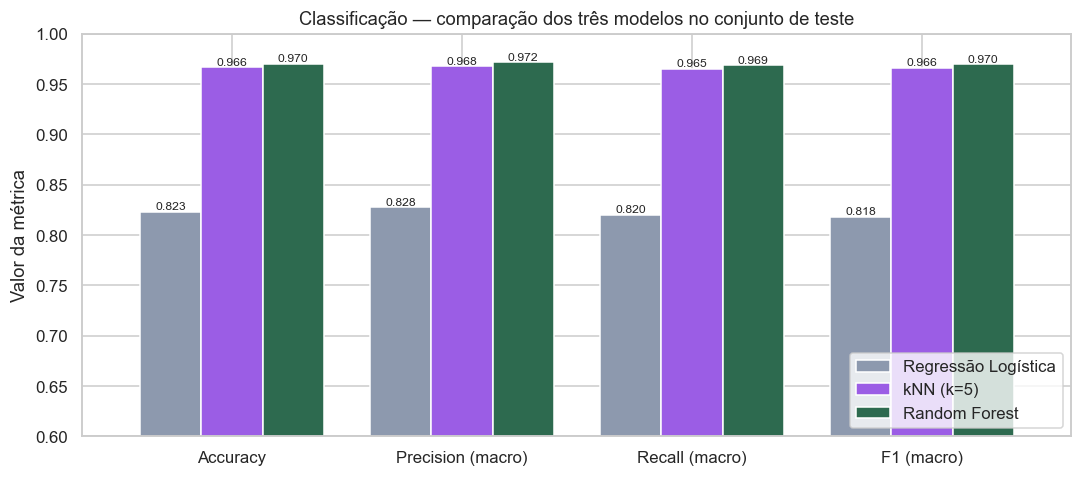

In [14]:
ax = resultados_clf.T.plot(kind="bar", figsize=(10, 4.5), color=CORES_MODELO, rot=0, width=0.8)
ax.set_ylim(0.6, 1.0)
ax.set_title("Classificação — comparação dos três modelos no conjunto de teste")
ax.set_ylabel("Valor da métrica")
ax.legend(loc="lower right")
for barras in ax.containers:
    ax.bar_label(barras, fmt="%.3f", fontsize=8)
plt.tight_layout(); plt.savefig("figuras/metricas_classificacao.png"); plt.show()

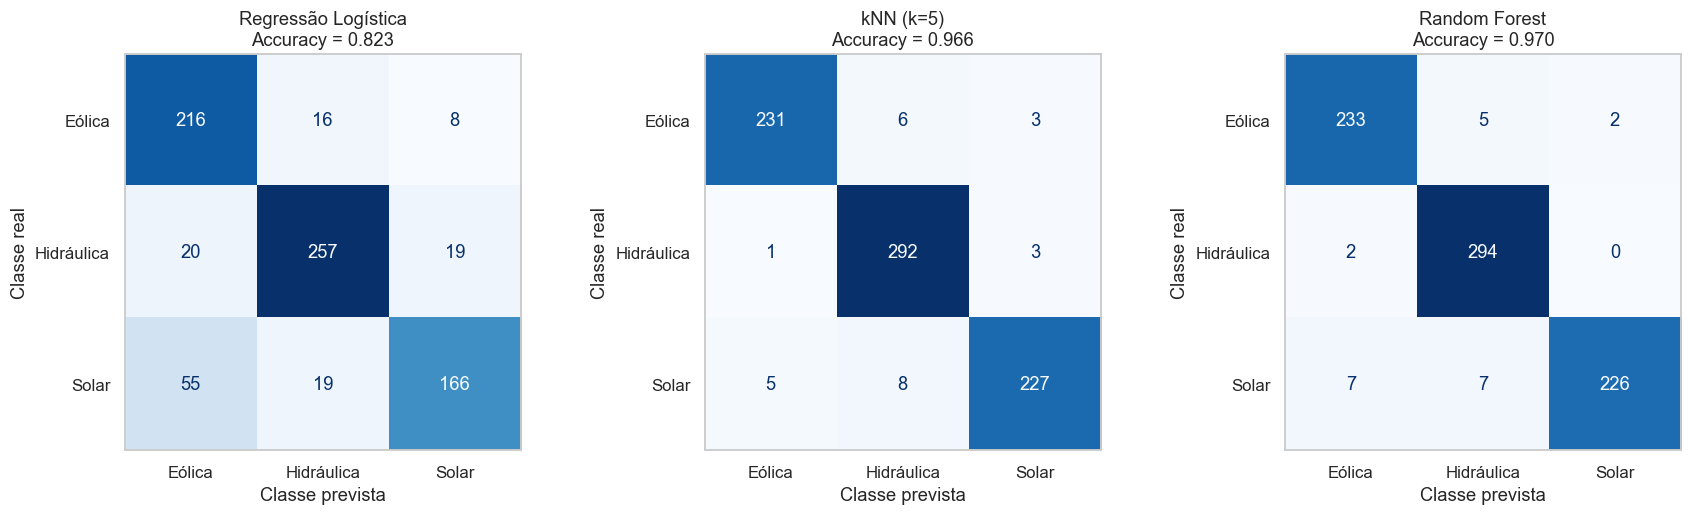

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (nome, y_prev) in zip(axes, previsoes_clf.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_teste, y_prev, labels=CLASSES),
                           display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{nome}\nAccuracy = {accuracy_score(y_teste, y_prev):.3f}")
    ax.set_xlabel("Classe prevista"); ax.set_ylabel("Classe real"); ax.grid(False)
plt.tight_layout(); plt.savefig("figuras/matrizes_confusao.png"); plt.show()

In [16]:
# Desempenho por classe de cada modelo
for nome, y_prev in previsoes_clf.items():
    print("=" * 60, "\n", nome)
    print(classification_report(y_teste, y_prev, digits=3))

 Regressão Logística
              precision    recall  f1-score   support

      Eólica      0.742     0.900     0.814       240
  Hidráulica      0.880     0.868     0.874       296
       Solar      0.860     0.692     0.767       240

    accuracy                          0.823       776
   macro avg      0.828     0.820     0.818       776
weighted avg      0.831     0.823     0.822       776

 kNN (k=5)
              precision    recall  f1-score   support

      Eólica      0.975     0.963     0.969       240
  Hidráulica      0.954     0.986     0.970       296
       Solar      0.974     0.946     0.960       240

    accuracy                          0.966       776
   macro avg      0.968     0.965     0.966       776
weighted avg      0.967     0.966     0.966       776

 Random Forest
              precision    recall  f1-score   support

      Eólica      0.963     0.971     0.967       240
  Hidráulica      0.961     0.993     0.977       296
       Solar      0.991     

### Verificação de robustez

Um único sorteio de teste pode favorecer um modelo por acaso. Repetimos a comparação com **validação cruzada estratificada de 5 partes** no conjunto completo (mesmos modelos e mesmos parâmetros) e, em seguida, medimos o efeito de remover as coordenadas (0, 0).

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
linhas = []
for nome, modelo in classificadores.items():
    r = cross_validate(modelo, X, y, cv=cv, scoring=["accuracy", "f1_macro"])
    linhas.append({"Modelo": nome,
                   "Accuracy média (CV 5)": r["test_accuracy"].mean(),
                   "Desvio": r["test_accuracy"].std(),
                   "F1 macro média (CV 5)": r["test_f1_macro"].mean()})
pd.DataFrame(linhas).set_index("Modelo").round(4)

,Accuracy média (CV 5),Desvio,F1 macro média (CV 5)
Modelo,,,
Regressão Logística,0.8160,0.0158,0.8097
kNN (k=5),0.9610,0.0044,0.9605
Random Forest,0.9727,0.0047,0.9720


In [27]:
sem_zero = dados[~coord_zero]
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    sem_zero[X.columns], sem_zero["fonte"], test_size=0.2, stratify=sem_zero["fonte"], random_state=SEMENTE)
for nome, modelo in classificadores.items():
    from sklearn.base import clone
    m = clone(modelo).fit(Xs_tr, ys_tr)
    print(f"{nome:22s} sem coordenadas (0,0): Accuracy = {accuracy_score(ys_te, m.predict(Xs_te)):.4f}")

Regressão Logística    sem coordenadas (0,0): Accuracy = 0.8227
kNN (k=5)              sem coordenadas (0,0): Accuracy = 0.9570
Random Forest          sem coordenadas (0,0): Accuracy = 0.9778


In [28]:
importancias = pd.Series(classificadores["Random Forest"].feature_importances_, index=X.columns)
print("Importância dos atributos na Random Forest:")
print(importancias.sort_values(ascending=False).round(3))

Importância dos atributos na Random Forest:
latitude       0.399
potencia_kw    0.323
longitude      0.278
dtype: float64


## 7. Interpretação — classificação

**Comparação dos três modelos (teste estratificado, 776 empreendimentos, média macro):**

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Regressão Logística | 0,825 | 0,828 | 0,821 | 0,820 |
| kNN (k=5) | 0,965 | 0,966 | 0,964 | 0,965 |
| Random Forest | 0,970 | 0,972 | 0,968 | 0,970 |

**Modelo escolhido: Random Forest.** Teve os melhores valores nas quatro métricas e também a maior média na validação cruzada (0,973), então a vantagem não depende de um sorteio específico. O kNN ficou perto (0,961 na CV), o que mostra que a **localização** carrega muita informação: empreendimentos vizinhos costumam ter a mesma fonte.

**Classes mais confundidas:**
- Na **Regressão Logística**, o erro mais frequente foi **Solar prevista como Eólica** (51 casos), seguido de Solar prevista como Hidráulica (22) e Hidráulica prevista como Eólica (20). Uma fronteira linear não separa regiões geográficas "em ilhas" (o agrupamento solar no Pará, as eólicas no Nordeste) nem lida bem com a potência muito assimétrica.
- Na **Random Forest** os poucos erros (23 de 776) são sobretudo **solares fora do agrupamento do Pará**, previstas como Eólica (8) ou Hidráulica (7): usinas solares de dezenas de MW no Nordeste têm potência e posição parecidas com parques eólicos, e algumas solares no Sudeste ficam próximas de pequenas hidrelétricas. Também há 5 eólicas previstas como Hidráulica.
- As linhas com coordenada (0, 0) só podem ser separadas pela potência; removê-las praticamente não altera o resultado (Random Forest: 0,971).

**Limitações de prever a fonte só com potência e localização:**
1. **A acurácia alta reflete a amostra, não uma regra física.** A consulta traz as primeiras 1.200 linhas de cada sigla; 732 das solares estão quase no mesmo ponto do Pará, quase todas com 1 kW. Basta o modelo reconhecer esse "ponto + 1 kW" para acertar a maior parte da classe Solar. No cadastro completo (com milhares de usinas solares em MG, BA, PI, SP etc.) o desempenho provavelmente cairia.
2. **Faltam variáveis físicas** que realmente determinam a fonte: recurso solar, velocidade média do vento, presença de rio/queda d'água, relevo, fase do empreendimento.
3. **Sobreposição real:** usinas solares e parques eólicos de 20–50 MW coexistem no mesmo semiárido nordestino; com essas três entradas eles podem ser indistinguíveis.
4. **Potência outorgada não é energia gerada**, e a contagem de exemplos por classe não representa a matriz energética.
5. Coordenadas inválidas (0, 0) mostram que é preciso limpar os dados antes de uma aplicação real.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para as coordenadas e o período escolhidos: **1º de abril a 30 de junho de 2025**, em horário local (`America/Recife`). São dados estimados por modelos/reanálise, não leituras de um sensor.

| Campo da API → CSV | Significado e unidade | Uso |
|---|---|---|
| `time` → `data_hora` | Data e hora local | Ordenar e separar por tempo; **não entra em X** |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m (°C) | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m (%) | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens (%) | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m (km/h) | Entrada |
| `time` → `hora` | Hora local, de 7 a 17 | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação global horizontal média da hora anterior (W/m²) | Alvo `y`; **não entra em X** |

### 8. Consultar o histórico meteorológico

In [30]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

try:
    resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
    if "hourly" not in resposta_meteo:
        raise ValueError("Resposta sem a seção hourly")
    horas_api = resposta_meteo["hourly"]
    print("Campos recebidos:", list(horas_api))
    print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
    print("Quantidade de horários:", len(horas_api["time"]))
except Exception as erro:
    horas_api = None
    print("API Open-Meteo indisponível neste ambiente:", erro)
    print("A análise usará o CSV versionado no repositório.")

Open-Meteo: consulta pública, sem token
Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 9. Gerar o CSV horário
As listas de `hourly` são alinhadas pelo índice. Mantemos as horas de 7h a 17h, descartamos linhas com valores ausentes e preservamos a ordem cronológica.

In [31]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
if horas_api is not None:
    linhas_regressao = []
    for indice, data_hora in enumerate(horas_api["time"]):
        hora = int(data_hora[11:13])
        valores = [horas_api[nome][indice] for nome in nomes_api]
        if 7 <= hora <= 17 and all(valor is not None for valor in valores):
            linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
    if len(linhas_regressao) < 100:
        raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
    with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
        escritor = csv.writer(arquivo)
        escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                           "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
        escritor.writerows(linhas_regressao)
    print("Horas válidas:", len(linhas_regressao))
    print("Salvo: meteo_regressao_orange.csv")
else:
    garantir_csv("meteo_regressao_orange.csv")

Horas válidas: 1001
Salvo: meteo_regressao_orange.csv


## 10. Análise exploratória — Open-Meteo

In [32]:
meteo = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig", parse_dates=["data_hora"])
meteo = meteo.sort_values("data_hora").reset_index(drop=True)
print("Linhas e colunas:", meteo.shape)
print("Período:", meteo["data_hora"].min(), "a", meteo["data_hora"].max())
print("Dias:", meteo["data_hora"].dt.date.nunique(), "| horas por dia:", meteo.groupby(meteo["data_hora"].dt.date).size().unique())
print("\nValores ausentes por coluna:")
print(meteo.isna().sum())
meteo.describe().round(1)

Linhas e colunas: (1001, 7)
Período: 2025-04-01 07:00:00 a 2025-06-30 17:00:00
Dias: 91 | horas por dia: [11]

Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.0,1001.0,1001.0,1001.0,1001.0,1001.0
mean,2025-05-16 12:00:00,28.9,50.5,55.1,15.5,12.0,472.9
min,2025-04-01 07:00:00,19.5,21.0,0.0,2.3,7.0,13.0
25%,2025-04-23 15:00:00,26.3,38.0,19.0,12.2,9.0,250.0
50%,2025-05-16 12:00:00,29.1,49.0,54.0,15.4,12.0,466.0
75%,2025-06-08 09:00:00,31.7,61.0,98.0,19.0,15.0,696.0
max,2025-06-30 17:00:00,36.1,95.0,100.0,30.1,17.0,1002.0
std,NaN,3.7,15.9,37.9,4.9,3.2,256.4


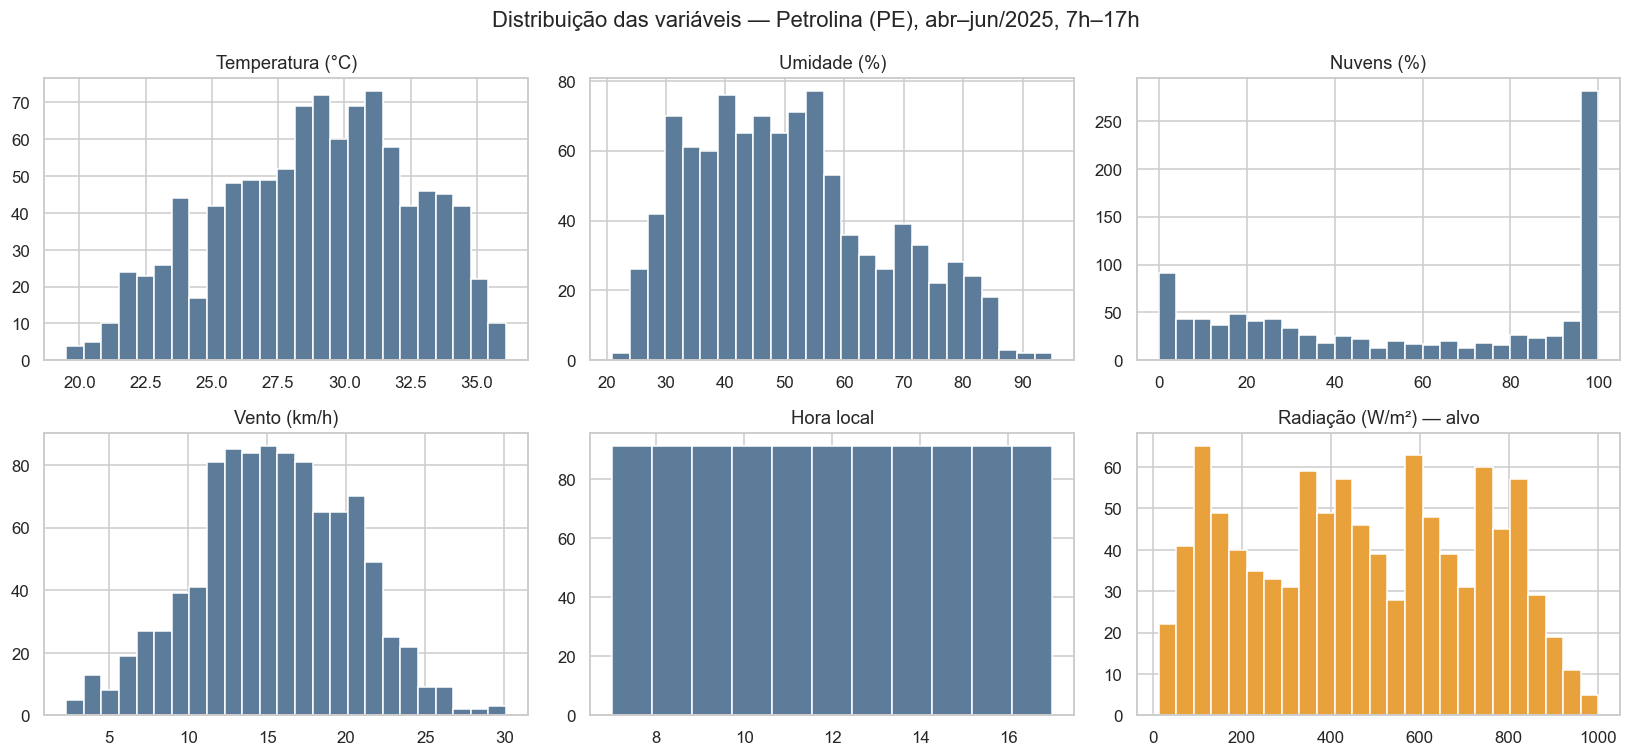

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
colunas = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"]
titulos = ["Temperatura (°C)", "Umidade (%)", "Nuvens (%)", "Vento (km/h)", "Hora local", "Radiação (W/m²) — alvo"]
for ax, col, tit in zip(axes.flat, colunas, titulos):
    ax.hist(meteo[col], bins=11 if col == "hora" else 25, color="#E9A23B" if col == "radiacao_w_m2" else "#5C7C99", edgecolor="white")
    ax.set_title(tit)
plt.suptitle("Distribuição das variáveis — Petrolina (PE), abr–jun/2025, 7h–17h")
plt.tight_layout(); plt.savefig("figuras/distribuicoes_meteo.png"); plt.show()

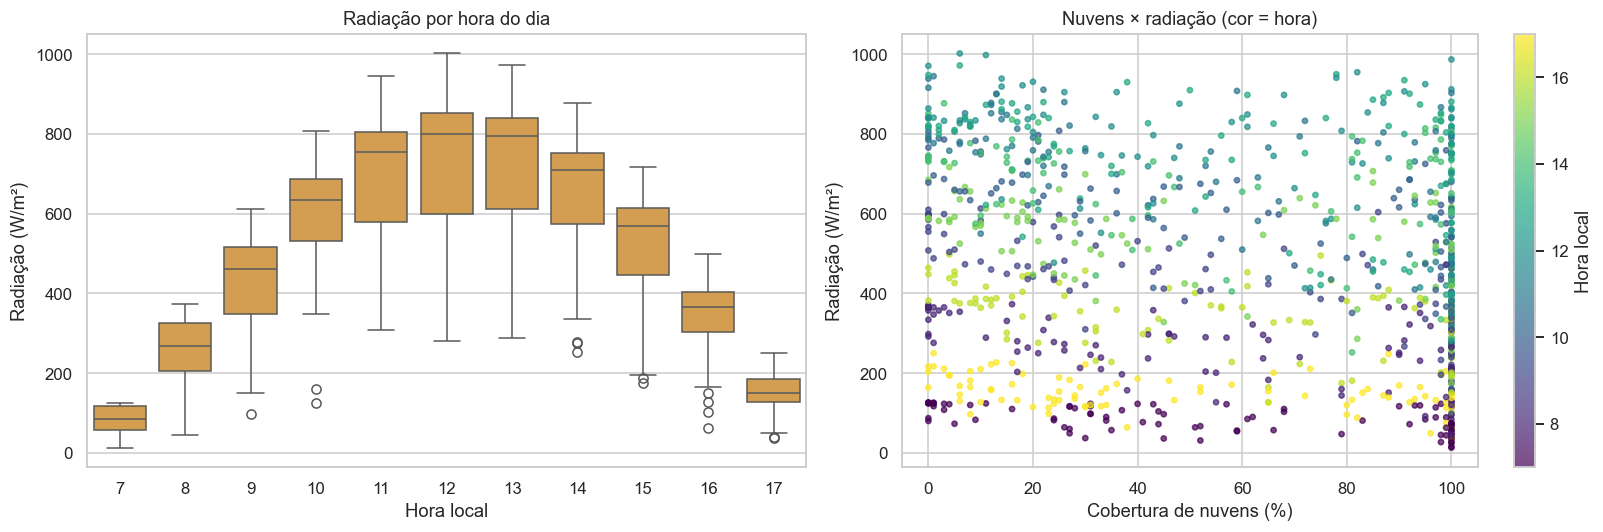

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=meteo, x="hora", y="radiacao_w_m2", color="#E9A23B", ax=axes[0])
axes[0].set_title("Radiação por hora do dia")
axes[0].set_xlabel("Hora local"); axes[0].set_ylabel("Radiação (W/m²)")

pts = axes[1].scatter(meteo["nuvens_pct"], meteo["radiacao_w_m2"], c=meteo["hora"], cmap="viridis", s=12, alpha=0.7)
plt.colorbar(pts, ax=axes[1], label="Hora local")
axes[1].set_title("Nuvens × radiação (cor = hora)")
axes[1].set_xlabel("Cobertura de nuvens (%)"); axes[1].set_ylabel("Radiação (W/m²)")
plt.tight_layout(); plt.savefig("figuras/radiacao_hora_nuvens.png"); plt.show()

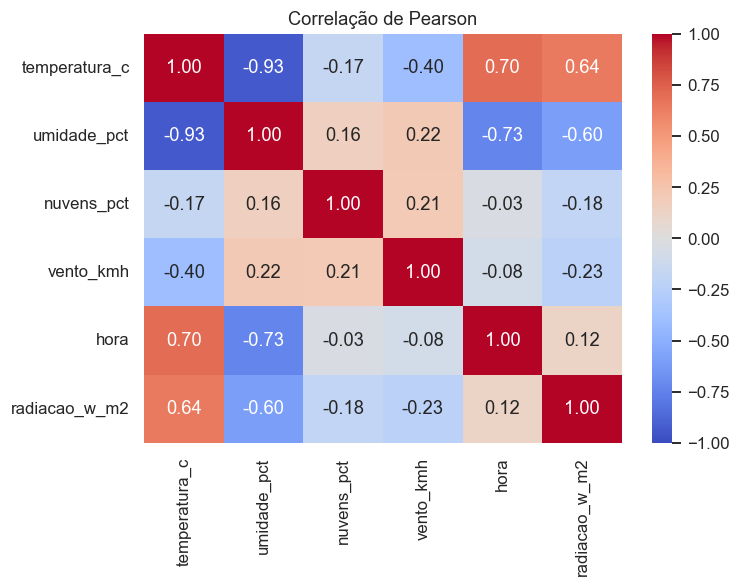

In [35]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(meteo[colunas].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação de Pearson")
plt.tight_layout(); plt.savefig("figuras/correlacao_meteo.png"); plt.show()

**O que a exploração mostra:**

- São **1.001 horas** (91 dias × 11 horas, das 7h às 17h), sem valores ausentes.
- **Hora:** a radiação tem forma de "sino" ao longo do dia — baixa às 7h (mediana 84 W/m²), máxima por volta de 12h–13h (mediana 799 W/m²) e baixa de novo às 17h. A correlação linear da hora com a radiação é quase zero (0,12) **justamente porque a relação não é linear**: sobe de manhã e desce à tarde.
- **Temperatura** (0,64) e **umidade** (-0,60) têm a maior correlação linear: o ar esquenta e seca quando o sol está forte. São efeitos da radiação, não causas.
- **Nuvens** reduzem a radiação dentro de cada hora (no gráfico, para a mesma cor, mais nuvem → menos radiação), mas o efeito é misturado com a hora, por isso a correlação simples é fraca (-0,18).

## 11. Definição de X e y e divisão temporal

- **X:** `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`.
- **y:** `radiacao_w_m2`.
- `data_hora` é usada **apenas** para ordenar e separar.

As linhas estão em ordem cronológica. Usamos as **primeiras 80% das horas para treino** e as **últimas 20% para teste**, sem embaralhar. Assim o modelo é avaliado em dias "futuros" que não viu, como numa previsão real; embaralhar colocaria horas vizinhas (quase iguais) no treino e no teste e deixaria o resultado otimista.

In [37]:
ENTRADAS = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
Xr = meteo[ENTRADAS]
yr = meteo["radiacao_w_m2"]

corte = int(len(meteo) * 0.8)
Xr_treino, Xr_teste = Xr.iloc[:corte], Xr.iloc[corte:]
yr_treino, yr_teste = yr.iloc[:corte], yr.iloc[corte:]
datas_teste = meteo["data_hora"].iloc[corte:]

print(f"Treino: {len(Xr_treino)} horas ({meteo['data_hora'].iloc[0]} a {meteo['data_hora'].iloc[corte-1]})")
print(f"Teste : {len(Xr_teste)} horas ({meteo['data_hora'].iloc[corte]} a {meteo['data_hora'].iloc[-1]})")

# Arquivos de treino e teste usados também no Orange (mesma divisão)
os.makedirs("orange", exist_ok=True)
meteo.iloc[:corte].to_csv("orange/meteo_treino_80.csv", index=False, date_format="%Y-%m-%dT%H:%M")
meteo.iloc[corte:].to_csv("orange/meteo_teste_20.csv", index=False, date_format="%Y-%m-%dT%H:%M")

Treino: 800 horas (2025-04-01 07:00:00 a 2025-06-12 14:00:00)
Teste : 201 horas (2025-06-12 15:00:00 a 2025-06-30 17:00:00)


## 12. Os três regressores

| Modelo | Configuração | Por que escolhemos |
|---|---|---|
| **Regressão Linear** | `LinearRegression()` | Referência simples e interpretável: cada entrada soma um efeito proporcional. Não precisa de padronização para prever. |
| **Árvore de Decisão** | `DecisionTreeRegressor(min_samples_leaf=2, min_samples_split=5, random_state=42)` | Divide os dados em regras ("se hora entre 10 e 14 e nuvens < 40%…"), capturando a curva da hora e interações. Configuração equivalente à do widget *Tree* do Orange. |
| **Random Forest** | `RandomForestRegressor(n_estimators=100, min_samples_split=5, random_state=42)` | Média de 100 árvores treinadas em amostras diferentes; reduz a variância de uma árvore única. |

In [38]:
regressores = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(min_samples_leaf=2, min_samples_split=5, random_state=SEMENTE),
    "Random Forest": RandomForestRegressor(n_estimators=100, min_samples_split=5, random_state=SEMENTE),
}

previsoes_reg, linhas = {}, []
for nome, modelo in regressores.items():
    modelo.fit(Xr_treino, yr_treino)
    y_prev = modelo.predict(Xr_teste)
    previsoes_reg[nome] = y_prev
    mse = mean_squared_error(yr_teste, y_prev)
    linhas.append({"Modelo": nome,
                   "MAE (W/m²)": mean_absolute_error(yr_teste, y_prev),
                   "MSE ((W/m²)²)": mse,
                   "RMSE (W/m²)": np.sqrt(mse),
                   "R²": r2_score(yr_teste, y_prev)})

resultados_reg = pd.DataFrame(linhas).set_index("Modelo")
resultados_reg.round(4).to_csv("resultados/metricas_regressao.csv")
resultados_reg.round(3)

,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Modelo,,,,
Regressão Linear,145.205,30034.201,173.304,0.360
Árvore de Decisão,86.679,14358.588,119.827,0.694
Random Forest,67.868,7457.423,86.356,0.841


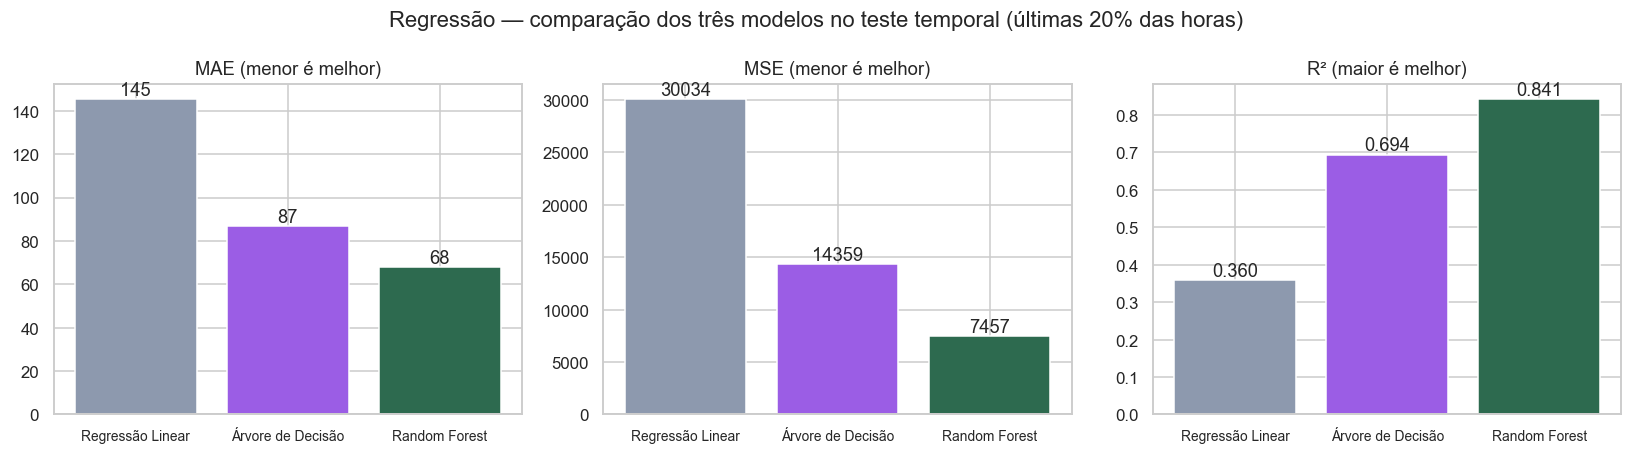

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (col, tit) in zip(axes, [("MAE (W/m²)", "MAE (menor é melhor)"),
                                  ("MSE ((W/m²)²)", "MSE (menor é melhor)"),
                                  ("R²", "R² (maior é melhor)")]):
    barras = ax.bar(resultados_reg.index, resultados_reg[col], color=CORES_MODELO)
    ax.bar_label(barras, fmt="%.3f" if col == "R²" else "%.0f")
    ax.set_title(tit); ax.tick_params(axis="x", labelsize=9)
plt.suptitle("Regressão — comparação dos três modelos no teste temporal (últimas 20% das horas)")
plt.tight_layout(); plt.savefig("figuras/metricas_regressao.png"); plt.show()

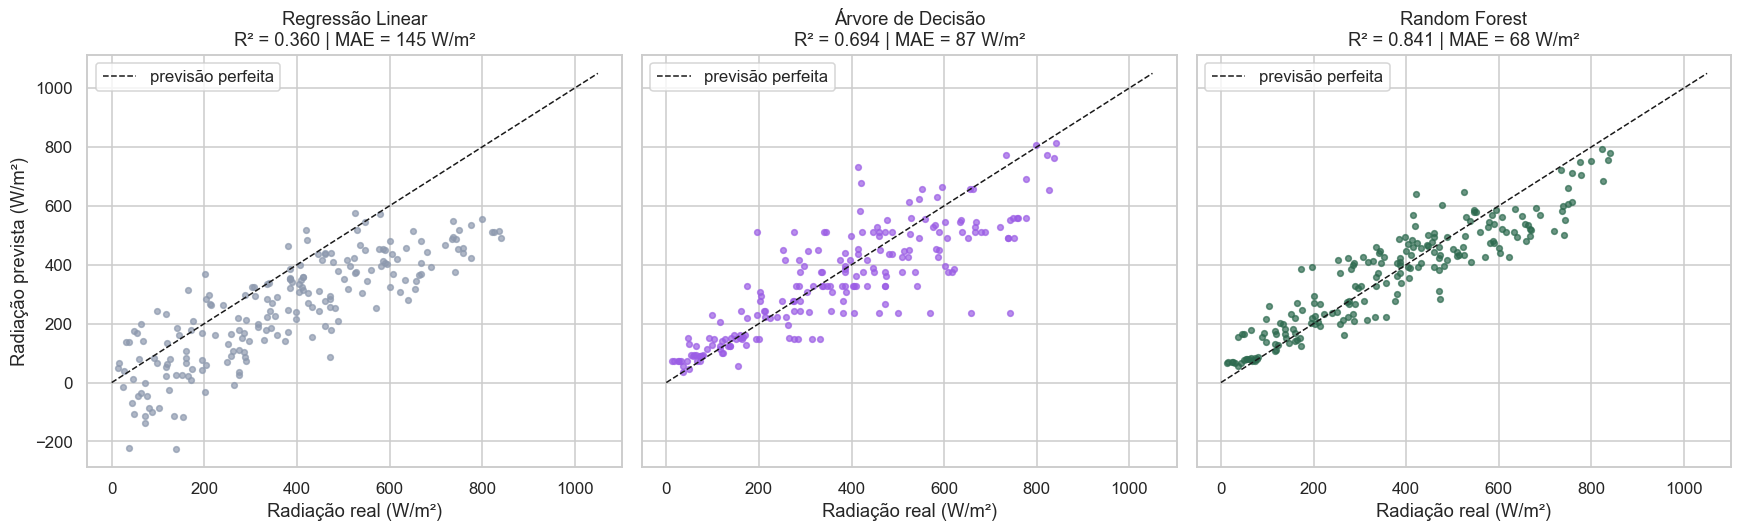

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, cor, (nome, y_prev) in zip(axes, CORES_MODELO, previsoes_reg.items()):
    ax.scatter(yr_teste, y_prev, s=14, alpha=0.7, color=cor)
    ax.plot([0, 1050], [0, 1050], "k--", lw=1, label="previsão perfeita")
    ax.set_title(f"{nome}\nR² = {r2_score(yr_teste, y_prev):.3f} | MAE = {mean_absolute_error(yr_teste, y_prev):.0f} W/m²")
    ax.set_xlabel("Radiação real (W/m²)")
    ax.legend(loc="upper left")
axes[0].set_ylabel("Radiação prevista (W/m²)")
plt.tight_layout(); plt.savefig("figuras/real_vs_previsto.png"); plt.show()

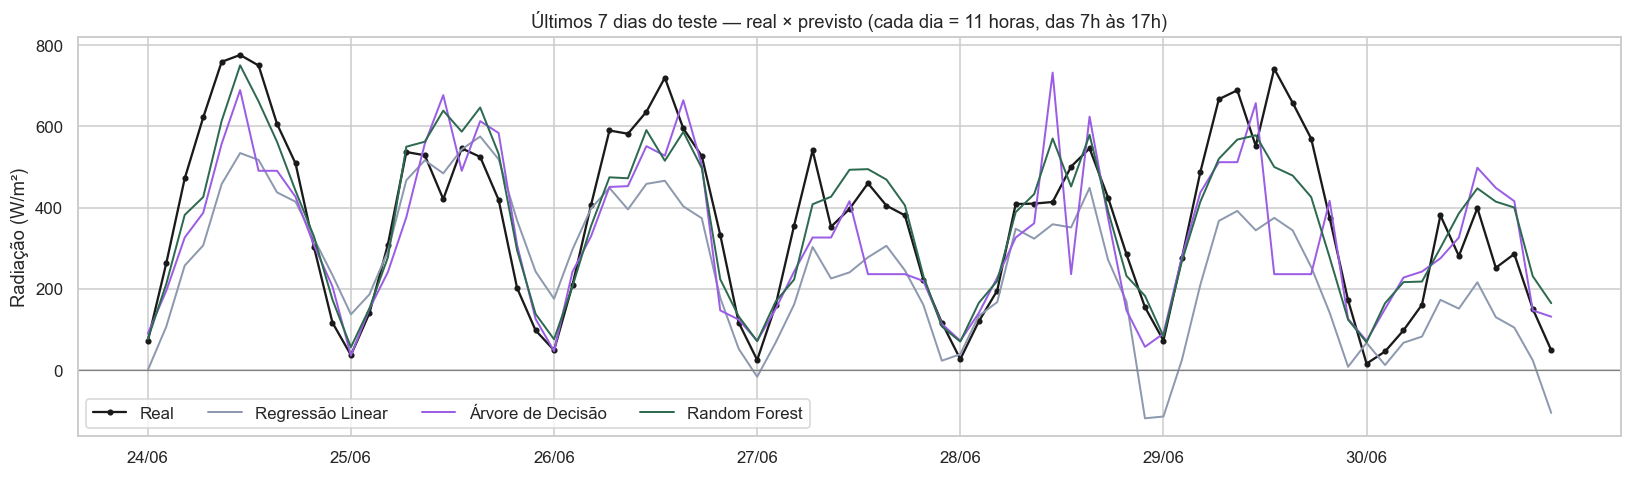

In [41]:
# Série temporal dos últimos 7 dias do teste: real × previsto
ultimos = datas_teste.dt.normalize() >= datas_teste.iloc[-1].normalize() - pd.Timedelta(days=6)
plt.figure(figsize=(15, 4.5))
x_pos = np.arange(ultimos.sum())
plt.plot(x_pos, yr_teste[ultimos].values, "k-o", ms=3, lw=1.5, label="Real")
for cor, (nome, y_prev) in zip(CORES_MODELO, previsoes_reg.items()):
    plt.plot(x_pos, y_prev[ultimos.values], "-", lw=1.3, color=cor, label=nome)
rotulos = datas_teste[ultimos].dt.strftime("%d/%m").values
plt.xticks(x_pos[::11], rotulos[::11], rotation=0)
plt.axhline(0, color="gray", lw=0.8)
plt.ylabel("Radiação (W/m²)"); plt.title("Últimos 7 dias do teste — real × previsto (cada dia = 11 horas, das 7h às 17h)")
plt.legend(ncol=4); plt.tight_layout(); plt.savefig("figuras/serie_teste.png"); plt.show()

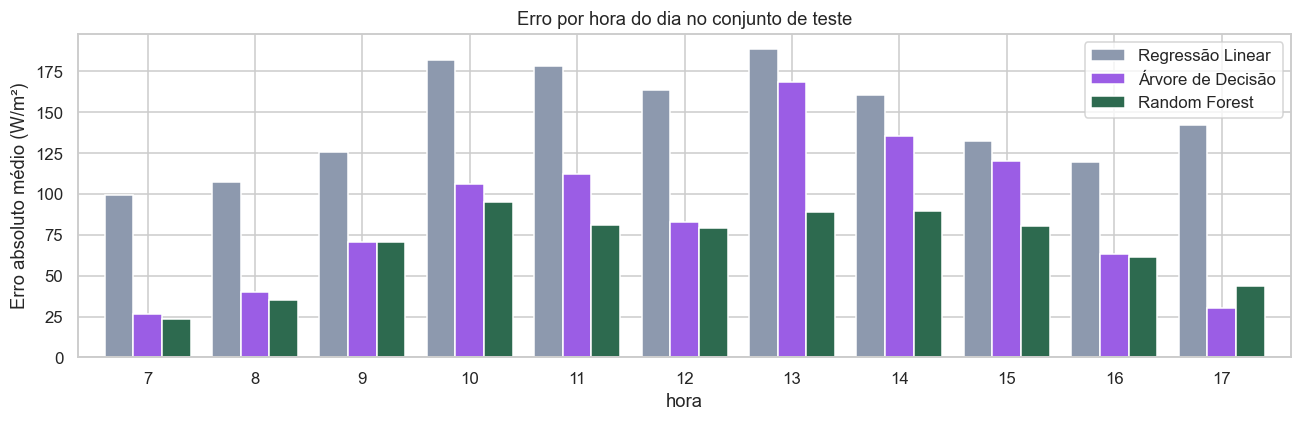

,Regressão Linear,Árvore de Decisão,Random Forest
hora,,,
7,100.0,27.0,24.0
8,107.0,40.0,35.0
9,126.0,71.0,71.0
10,182.0,106.0,95.0
11,178.0,112.0,81.0
12,164.0,83.0,79.0
13,189.0,169.0,89.0
14,160.0,136.0,90.0
15,133.0,120.0,80.0


In [42]:
# Erro absoluto médio por hora do dia
erro_hora = pd.DataFrame({nome: np.abs(yr_teste.values - p) for nome, p in previsoes_reg.items()})
erro_hora["hora"] = Xr_teste["hora"].values
erro_hora = erro_hora.groupby("hora").mean()
ax = erro_hora.plot(kind="bar", figsize=(12, 4), color=CORES_MODELO, rot=0, width=0.8)
ax.set_ylabel("Erro absoluto médio (W/m²)"); ax.set_title("Erro por hora do dia no conjunto de teste")
plt.tight_layout(); plt.savefig("figuras/erro_por_hora.png"); plt.show()
erro_hora.round(0)

In [43]:
coefs = pd.Series(regressores["Regressão Linear"].coef_, index=ENTRADAS)
imp = pd.Series(regressores["Random Forest"].feature_importances_, index=ENTRADAS)
pd.DataFrame({"Coeficiente da Regressão Linear (W/m² por unidade)": coefs.round(2),
              "Importância na Random Forest": imp.round(3)}).sort_values("Importância na Random Forest", ascending=False)

,Coeficiente da Regressão Linear (W/m² por unidade),Importância na Random Forest
hora,-63.78,0.492
temperatura_c,97.89,0.302
umidade_pct,1.36,0.173
nuvens_pct,-0.26,0.020
vento_kmh,10.09,0.014


## 13. Interpretação — regressão

**Comparação dos três modelos (teste temporal: 201 horas de 12/06/2025 15h a 30/06/2025):**

| Modelo | MAE (W/m²) | MSE ((W/m²)²) | RMSE (W/m²) | R² |
|---|---:|---:|---:|---:|
| Regressão Linear | 145,2 | 30.034 | 173,3 | 0,360 |
| Árvore de Decisão | 86,7 | 14.359 | 119,8 | 0,694 |
| Random Forest | 67,9 | 7.457 | 86,4 | 0,841 |

**Modelo escolhido: Random Forest.** As três métricas apontam para ele: menor MAE (erro médio de ~68 W/m²), menor MSE e maior R² (explica ~84% da variação da radiação nas semanas de teste). A Árvore de Decisão fica no meio: captura a curva diária, mas uma única árvore é instável e gera previsões "em degraus". A Regressão Linear é a pior porque assume relações retas — chega a prever **radiação negativa** em algumas horas, algo fisicamente impossível.

**Papel da hora do dia:** a hora define a posição do Sol — e, portanto, o máximo de radiação possível naquele momento. A relação é em forma de sino (pico ao meio-dia), por isso:
- a **Regressão Linear** não consegue usá-la: uma reta só sobe ou só desce. Ela recebe um coeficiente de -63,8 W/m² por hora (apenas "desconta" a tarde, quando a temperatura ainda está alta e o sol já está baixo) e se apoia na temperatura como pista indireta do sol forte. O resultado é um erro alto em **todas** as horas (100–190 W/m², veja o gráfico de erro por hora);
- os modelos de **árvore** dividem o dia em faixas de hora e combinam com temperatura, umidade e nuvens. Na Random Forest, a hora é a variável mais importante (0,49), seguida de temperatura e umidade (0,47 somadas). Às 7–8h e às 16–17h o erro das árvores fica em 25–60 W/m², porque a hora praticamente define a radiação possível.

**Erros:** os maiores erros da Random Forest aparecem entre 10h e 15h (~80–95 W/m² em média), quando a nebulosidade faz a radiação variar muito. A cobertura de nuvens em % não informa a espessura da nuvem: há horas com 100% de nuvens e 420 W/m², e outras com 100% e menos de 200 W/m². Também há uma limitação temporal: o teste é o fim de junho (perto do solstício de inverno, Sol mais baixo; radiação média de 373 W/m² contra 498 W/m² no treino), e o modelo não tem nenhuma variável que represente a época do ano.

**Por que radiação não é geração elétrica:**
1. **Unidade diferente:** W/m² é potência por área que chega ao solo; geração é energia elétrica (kWh) produzida por um sistema. Para chegar nela é preciso multiplicar pela área dos módulos e integrar no tempo.
2. **Eficiência e perdas:** a conversão depende da eficiência do módulo (~18–22%), da temperatura das células (calor reduz a eficiência), do inversor, de cabos, sujeira e sombreamento.
3. **Geometria:** a variável é a radiação **global horizontal**; um painel inclinado e orientado recebe outra irradiância (plano do painel).
4. **Dados estimados:** os valores do Open-Meteo vêm de modelos/reanálise para uma coordenada, não de um piranômetro ou de uma usina real.

Portanto, o modelo estima **o recurso solar disponível**, um passo anterior à previsão de geração de uma usina fotovoltaica.

# Conclusões gerais

| Tarefa | Melhor modelo | Resultado no teste | Principal limitação |
|---|---|---|---|
| Classificação da fonte (ANEEL) | Random Forest | Accuracy 0,970, F1 macro 0,970 | Amostra não aleatória (primeiras 1.200 linhas por sigla); só três entradas |
| Regressão da radiação (Open-Meteo) | Random Forest | MAE 67,9 W/m², R² 0,841 | Relação não linear com a hora; sem variável de época do ano; radiação ≠ geração |

Nas duas tarefas o modelo **ensemble de árvores** superou o modelo linear, porque as relações entre entradas e alvo não são lineares (regiões geográficas na classificação; curva diária da hora na regressão). A atividade complementar no **Orange Data Mining** reproduz as duas tarefas com os mesmos algoritmos — veja a pasta `orange/` e o README do repositório.

**Fontes:** [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) · [Open-Meteo — API histórica](https://open-meteo.com/en/docs/historical-weather-api) · [scikit-learn](https://scikit-learn.org/)